In [1]:
import pandas as pd

df = pd.read_json("/Users/suyashmali/Thesis/LLM/icecat_data_train.json")

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("max_colwidth", None)

In [3]:
df.head(5)

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,Description.Disclaimer,Description.ID,Description.LeafletPDFURL,Description.LongDesc,Description.LongProductName,Description.ManualPDFSize,Description.ManualPDFURL,Description.MiddleDesc,Description.PDFSize,Description.URL,Description.Updated,EndOfLifeDate,GTIN,IcecatId,ProductFamily.ProductFamilyID,ProductName,ProductSeries.SeriesID,ReleaseDate,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Title,Description.WarrantyInfo,Description,ProductFamily.Language,ProductFamily.Value,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names
1072689,ASUS,,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,ASUS,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,K31CD-IT049T,[],153,EN,PCs/Workstations,,57169981.0,,"<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality and reliability</b><br>\nASUS desktop PCs are subjected to a 

In [4]:
# Drop rows where pathlist_names is missing or not a string
df = df[df['pathlist_names'].notnull() & df['pathlist_names'].apply(lambda x: isinstance(x, str))]

# Keep only those rows where pathlist_names has exactly 2 '>' → which means 3 levels (A > B > C)
df_level = df[df['pathlist_names'].apply(lambda x: x.count('>') == 2)]

print(f"✅ Found {len(df_level)} products with exactly 3-level categories.")

✅ Found 289865 products with exactly 3-level categories.


In [5]:
df_level.head()

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,Description.Disclaimer,Description.ID,Description.LeafletPDFURL,Description.LongDesc,Description.LongProductName,Description.ManualPDFSize,Description.ManualPDFURL,Description.MiddleDesc,Description.PDFSize,Description.URL,Description.Updated,EndOfLifeDate,GTIN,IcecatId,ProductFamily.ProductFamilyID,ProductName,ProductSeries.SeriesID,ReleaseDate,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Title,Description.WarrantyInfo,Description,ProductFamily.Language,ProductFamily.Value,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names
1072689,ASUS,,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,ASUS,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,K31CD-IT049T,[],153,EN,PCs/Workstations,,57169981.0,,"<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality and reliability</b><br>\nASUS desktop PCs are subjected to a 

In [11]:
def load_and_preprocess(file_path):
    """
    Load JSON dataset, filter for at least 3 taxonomy levels,
    split into Level1–Level4, clean text, and preserve Level4 for later.
    """
    import pandas as pd

    # Load JSON
    df = pd.read_json("/Users/suyashmali/Thesis/LLM/icecat_data_train.json")

    # Filter for 3+ levels in taxonomy
    df = df[df['pathlist_names'].notnull()]
    df = df[df['pathlist_names'].str.count('>') >= 2].reset_index(drop=True)
    df.fillna("", inplace=True)

    # Keep only important text columns
    cols = [
        "Title", "BrandInfo.BrandName", "ProductName", "Category.Name.Value",
        "SummaryDescription.LongSummaryDescription", "SummaryDescription.ShortSummaryDescription",
        "Description.LongProductName", "Description.LongDesc", "pathlist_names"
    ]
    for col in cols:
        if col not in df.columns:
            df[col] = ""

    # Split taxonomy
    path_split = df['pathlist_names'].str.split('>', expand=True)
    df['Level1'] = path_split[0].str.strip()
    df['Level2'] = path_split[1].str.strip()
    df['Level3'] = path_split[2].str.strip()
    if path_split.shape[1] > 3:
        df['Level4'] = path_split[3].str.strip()
    else:
        df['Level4'] = ""

    return df


In [12]:
df = load_and_preprocess("df")

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_26931/368482503.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("", inplace=True)


In [13]:
# df.head(50)

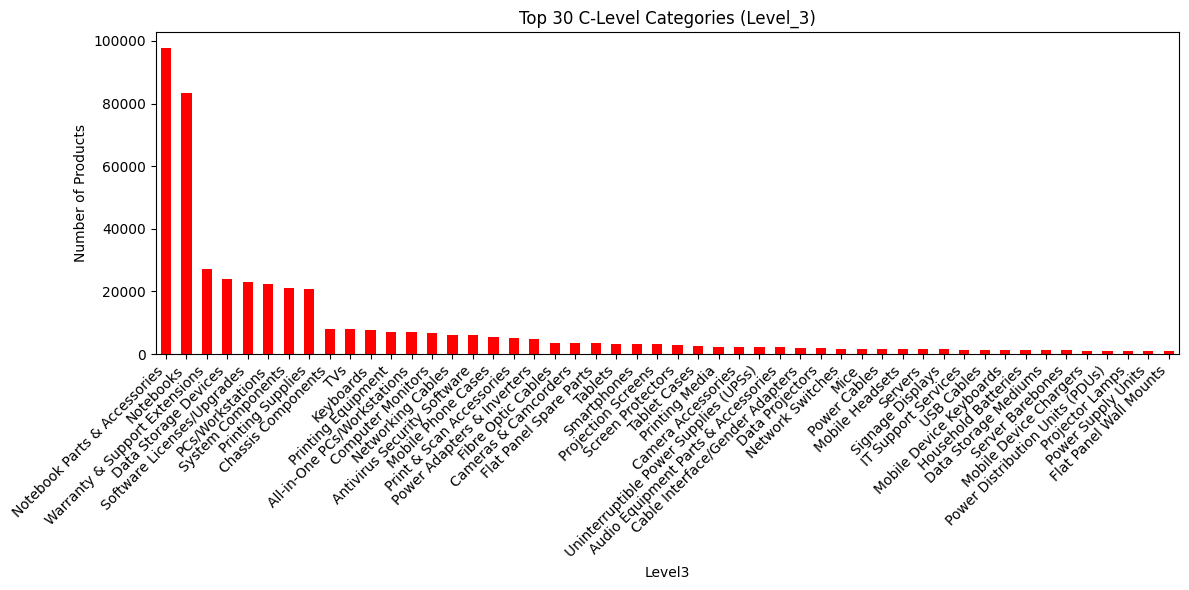

In [14]:
import matplotlib.pyplot as plt

# Count B-level categories
b_counts = df['Level3'].value_counts()


# Plot Top 20
plt.figure(figsize=(12, 6))
b_counts.head(50).plot(kind='bar', color='red')
plt.title("Top 30 C-Level Categories (Level_3)")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


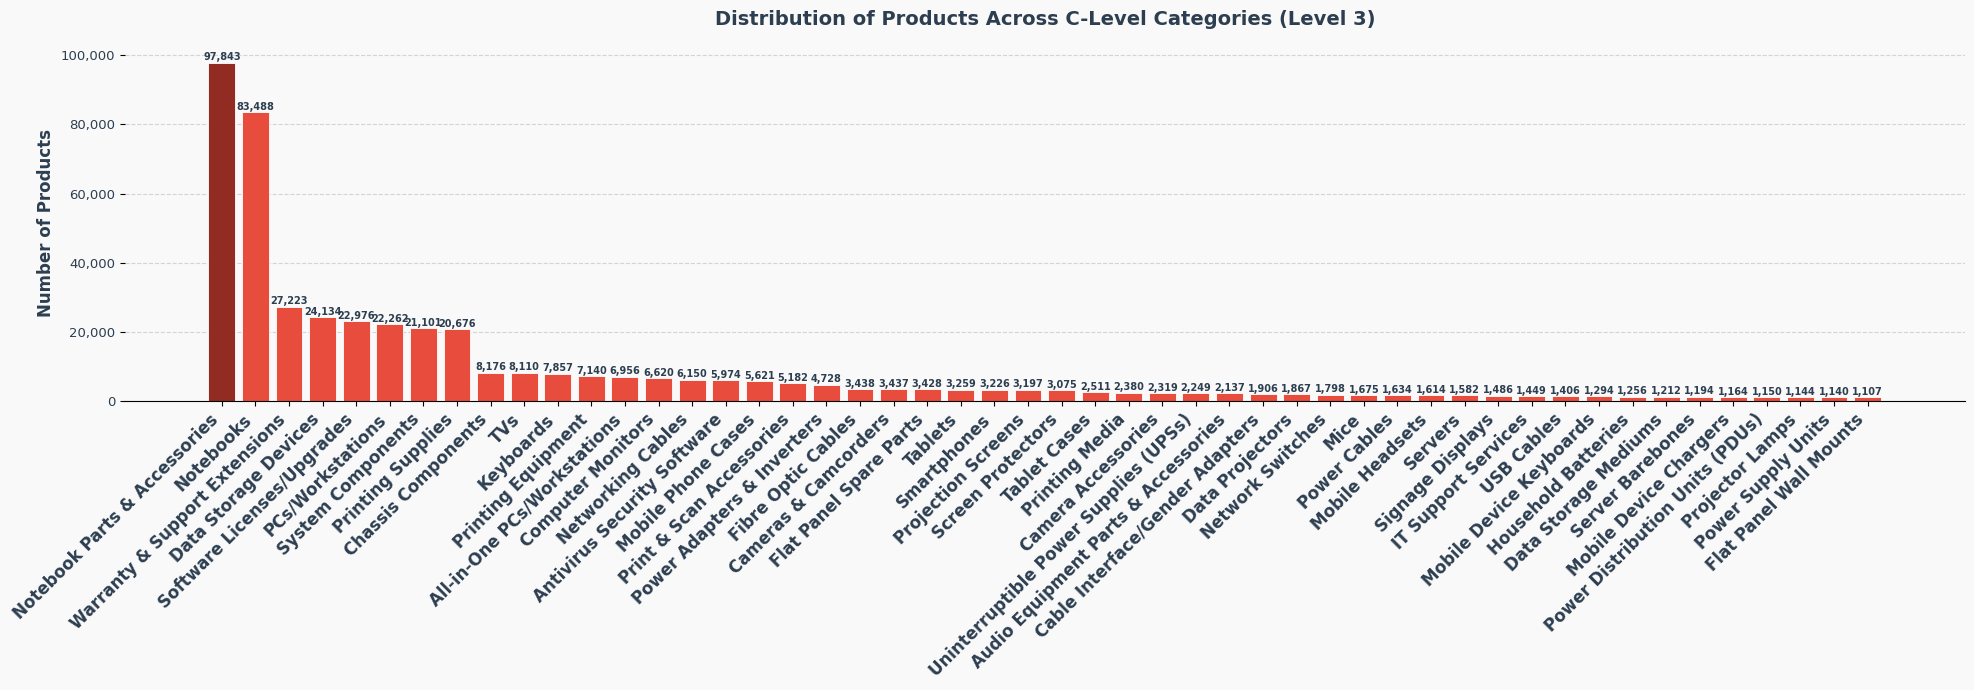

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

b_counts = df['Level3'].value_counts().head(50)

fig, ax = plt.subplots(figsize=(20, 7))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

# Highlight top bar differently
colors = ['#922b21' if i == 0 else '#e74c3c' for i in range(len(b_counts))]

bars = ax.bar(b_counts.index, b_counts.values, color=colors, edgecolor='white', linewidth=0.6)

# Labels on top of bars
for bar, count in zip(bars, b_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'{count:,}',
            ha='center', va='bottom', fontsize=7, fontweight='bold', color='#2c3e50')

# Styling
ax.set_title('Distribution of Products Across C-Level Categories (Level 3)',
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.set_ylabel('Number of Products', fontsize=12,  fontweight='bold', color='#2c3e50')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='x', rotation=45)
plt.xticks(ha='right', fontsize=12, fontweight='bold', color='#2c3e50')
plt.yticks(fontsize=9.5, color='#2c3e50')

plt.tight_layout()
plt.savefig('level3_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import pandas as pd

summary = pd.DataFrame({
    'Hierarchy Level': ['Level 1', 'Level 2', 'Level 3', 'Level 4'],
    'Non-Null Count': [df['Level1'].notna().sum(), df['Level2'].notna().sum(),
                       df['Level3'].notna().sum(), df['Level4'].notna().sum()],
    'Null Count':     [df['Level1'].isna().sum(), df['Level2'].isna().sum(),
                       df['Level3'].isna().sum(), df['Level4'].isna().sum()],
    'Unique Categories': [df['Level1'].nunique(), df['Level2'].nunique(),
                          df['Level3'].nunique(), df['Level4'].nunique()]
})

print(summary.to_string(index=False))

Hierarchy Level  Non-Null Count  Null Count  Unique Categories
        Level 1          489902           0                  1
        Level 2          489902           0                 17
        Level 3          489902           0                231
        Level 4          200037      289865                161


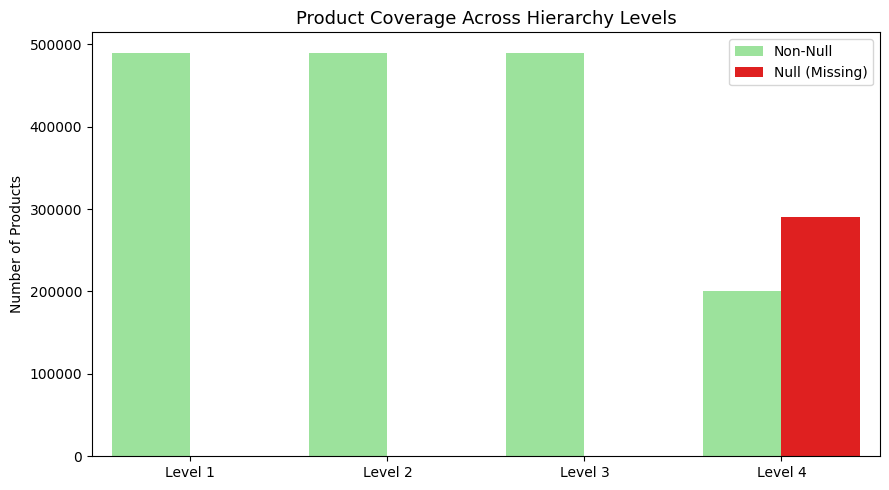

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

levels = ['Level 1', 'Level 2', 'Level 3', 'Level 4']
non_null = [df['Level1'].notna().sum(), df['Level2'].notna().sum(),
            df['Level3'].notna().sum(), df['Level4'].notna().sum()]
null_counts = [df['Level1'].isna().sum(), df['Level2'].isna().sum(),
               df['Level3'].isna().sum(), df['Level4'].isna().sum()]

plot_df = pd.DataFrame({
    'Level': levels * 2,
    'Count': non_null + null_counts,
    'Type': ['Non-Null'] * 4 + ['Null (Missing)'] * 4
})

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x='Level', y='Count', hue='Type',
            palette={'Non-Null': 'lightgreen', 'Null (Missing)': 'red'})

plt.title("Product Coverage Across Hierarchy Levels", fontsize=13)
plt.ylabel("Number of Products")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [17]:
df['Level3'].value_counts()

Level3
Notebook Parts & Accessories     97843
Notebooks                        83488
Warranty & Support Extensions    27223
Data Storage Devices             24134
Software Licenses/Upgrades       22976
                                 ...  
AV Conferencing Bridges             17
ISDN Access Devices                 17
Numeric Keypads                     17
Cassette Players                    16
Smart TV Boxes                      16
Name: count, Length: 231, dtype: int64

In [18]:
df['Level3'].nunique()

231

In [19]:
df["Level4"].nunique()

161

In [20]:
df['Level4']

0                         None
1         Notebook Spare Parts
2                         None
3                         None
4                         None
                  ...         
489897                    None
489898    Notebook Spare Parts
489899                    None
489900                    None
489901    Notebook Spare Parts
Name: Level4, Length: 489902, dtype: object

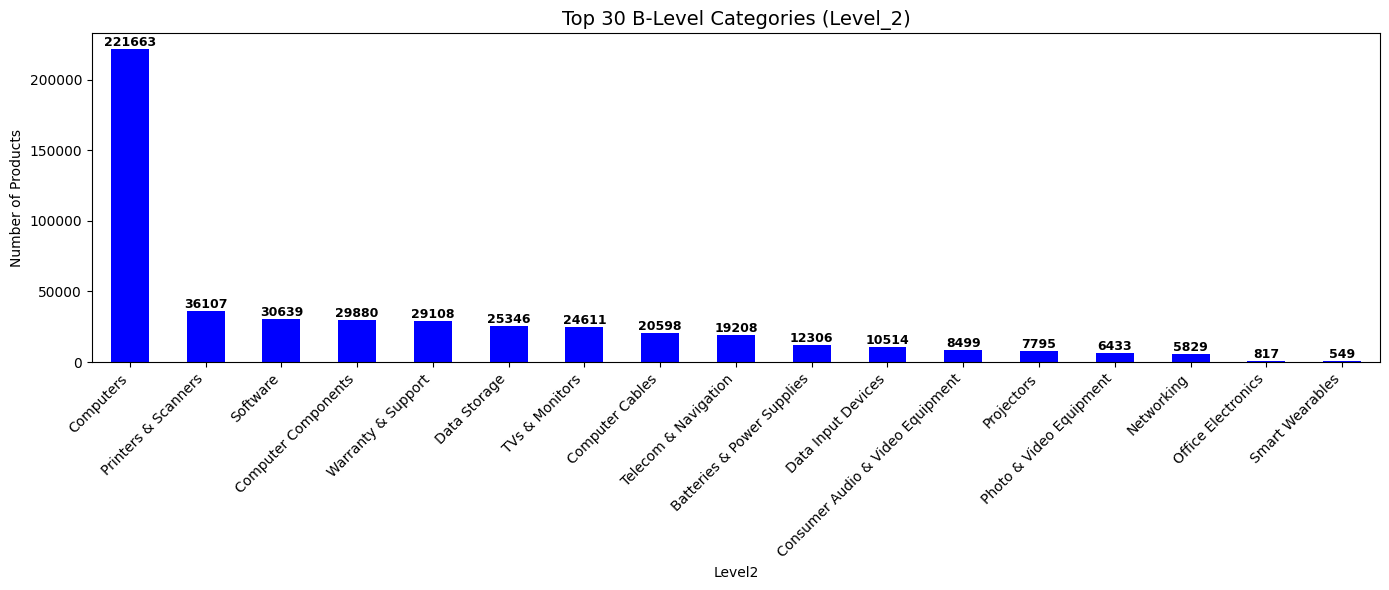

In [21]:
import matplotlib.pyplot as plt

# Count Level_2 categories
b_counts = df['Level2'].value_counts()

# Plot Top 20
plt.figure(figsize=(14, 6))
ax = b_counts.head(30).plot(kind='bar', color='blue')

# Add labels on top of bars
for i, count in enumerate(b_counts.head(30).values):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Top 30 B-Level Categories (Level_2)", fontsize=14)
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


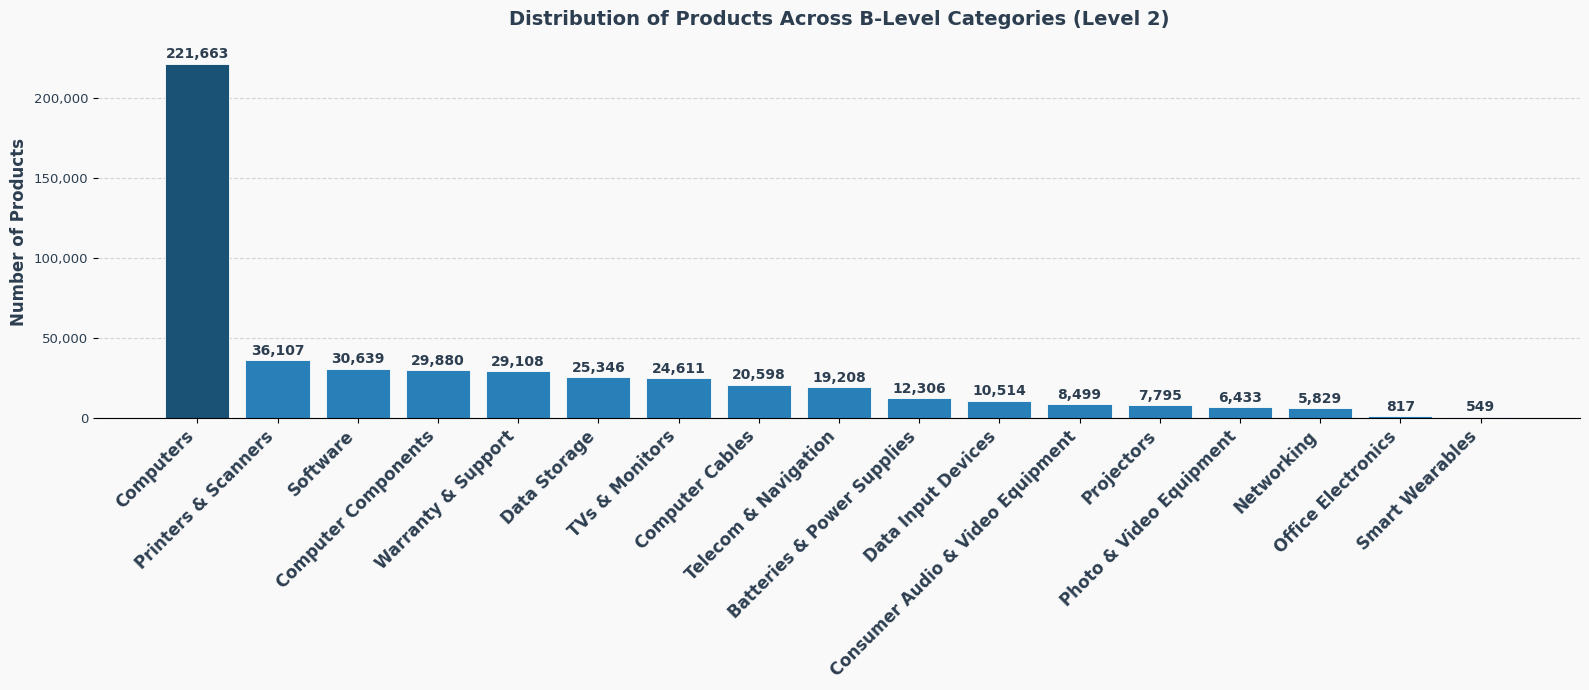

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

b_counts = df['Level2'].value_counts().head(30)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

# Color: highlight top bar differently
colors = ['#1a5276' if i == 0 else '#2980b9' for i in range(len(b_counts))]

bars = ax.bar(b_counts.index, b_counts.values, color=colors, edgecolor='white',linewidth=0.6)

# Labels on top of bars
for bar, count in zip(bars, b_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1500,
            f'{count:,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')

# Styling
ax.set_title('Distribution of Products Across B-Level Categories (Level 2)',
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.set_ylabel('Number of Products', fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.grid(True, linestyle='--',alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='x', rotation=45)
plt.xticks(ha='right', fontsize=12, fontweight='bold', color='#2c3e50')
plt.yticks(fontsize=9.5, color='#2c3e50')

plt.tight_layout()
plt.savefig('level2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# plt.savefig("level2_category_imbalance.png", dpi=300)


In [16]:
df[df["Level2"] == "Computers"].shape[0]


221663

In [17]:
# How many unique brands exist under Level_2 = "Computers"
df[df["Level2"] == "Computers"]["BrandInfo.BrandName"].nunique()


130

In [18]:
df.columns

Index(['Brand', 'BrandInfo.BrandLocalName', 'BrandInfo.BrandLogo',
       'BrandInfo.BrandName', 'BrandLogo', 'BrandPartCode', 'BulletPoints',
       'Category.CategoryID', 'Category.Name.Language', 'Category.Name.Value',
       'Description.Disclaimer', 'Description.ID', 'Description.LeafletPDFURL',
       'Description.LongDesc', 'Description.LongProductName',
       'Description.ManualPDFSize', 'Description.ManualPDFURL',
       'Description.MiddleDesc', 'Description.PDFSize', 'Description.URL',
       'Description.Updated', 'EndOfLifeDate', 'GTIN', 'IcecatId',
       'ProductFamily.ProductFamilyID', 'ProductName',
       'ProductSeries.SeriesID', 'ReleaseDate',
       'SummaryDescription.LongSummaryDescription',
       'SummaryDescription.ShortSummaryDescription', 'Title',
       'Description.WarrantyInfo', 'Description', 'ProductFamily.Language',
       'ProductFamily.Value', 'ProductSeries.Language', 'ProductSeries.Value',
       'BulletPoints.BulletPointsId', 'BulletPoints.Langua

In [19]:
df["Level2"].nunique()

17

In [20]:
# Drop rows where pathlist_names is missing or not a string
df = df[df['pathlist_names'].notnull() & df['pathlist_names'].apply(lambda x: isinstance(x, str))]

# Keep only those rows where pathlist_names has exactly 2 '>' → which means 3 levels (A > B > C)
df_level = df[df['pathlist_names'].apply(lambda x: x.count('>') == 2)]

print(f"✅ Found {len(df_level)} products with exactly 3-level categories.")

✅ Found 289865 products with exactly 3-level categories.


In [21]:
df_level.head()

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,Description.Disclaimer,Description.ID,Description.LeafletPDFURL,Description.LongDesc,Description.LongProductName,Description.ManualPDFSize,Description.ManualPDFURL,Description.MiddleDesc,Description.PDFSize,Description.URL,Description.Updated,EndOfLifeDate,GTIN,IcecatId,ProductFamily.ProductFamilyID,ProductName,ProductSeries.SeriesID,ReleaseDate,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Title,Description.WarrantyInfo,Description,ProductFamily.Language,ProductFamily.Value,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names,Level1,Level2,Level3,Level4
0,ASUS,,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,ASUS,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,K31CD-IT049T,[],153,EN,PCs/Workstations,,57169981.0,,"<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality and reliability</b><br>\nASUS desktop P

In [22]:
df_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 289865 entries, 0 to 489900
Data columns (total 49 columns):
 #   Column                                      Non-Null Count   Dtype 
---  ------                                      --------------   ----- 
 0   Brand                                       289865 non-null  object
 1   BrandInfo.BrandLocalName                    289865 non-null  object
 2   BrandInfo.BrandLogo                         289865 non-null  object
 3   BrandInfo.BrandName                         289865 non-null  object
 4   BrandLogo                                   289865 non-null  object
 5   BrandPartCode                               289865 non-null  object
 6   BulletPoints                                289865 non-null  object
 7   Category.CategoryID                         289865 non-null  int64 
 8   Category.Name.Language                      289865 non-null  object
 9   Category.Name.Value                         289865 non-null  object
 10  Description.D

In [23]:
df_level['Level3'].nunique()

209

In [24]:
fields_to_keep = [
    # "Title",
    # "BrandInfo.BrandName",
    # "ProductName", 
    "SummaryDescription.LongSummaryDescription",
    # "SummaryDescription.ShortSummaryDescription",
    # "Description.LongProductName",
    # "Description.LongDesc",
]


# Combine all text fields into one column for LLM or clustering
df_level['metadata_text'] = df_level[fields_to_keep].astype(str).apply(lambda x: ' | '.join(x), axis=1)

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_14648/1918416926.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_level['metadata_text'] = df_level[fields_to_keep].astype(str).apply(lambda x: ' | '.join(x), axis=1)


In [25]:
df_level.head(5)

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,Description.Disclaimer,Description.ID,Description.LeafletPDFURL,Description.LongDesc,Description.LongProductName,Description.ManualPDFSize,Description.ManualPDFURL,Description.MiddleDesc,Description.PDFSize,Description.URL,Description.Updated,EndOfLifeDate,GTIN,IcecatId,ProductFamily.ProductFamilyID,ProductName,ProductSeries.SeriesID,ReleaseDate,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Title,Description.WarrantyInfo,Description,ProductFamily.Language,ProductFamily.Value,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names,Level1,Level2,Level3,Level4,metadata_text
0,ASUS,,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,ASUS,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,K31CD-IT049T,[],153,EN,PCs/Workstations,,57169981.0,,"<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality and reliability</b><br>\n

In [26]:
import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags if any
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove special characters except common ones
    text = re.sub(r'[^a-zA-Z0-9\s\-/.,]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_level['metadata_clean'] = df_level['metadata_text'].apply(clean_text)

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_14648/2206095748.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_level['metadata_clean'] = df_level['metadata_text'].apply(clean_text)


In [27]:
fields_to_keep = [
    # "Title",
    # "BrandInfo.BrandName",
    # "ProductName",
    # "Category.Name.Value",  
    "SummaryDescription.LongSummaryDescription",
    # "SummaryDescription.ShortSummaryDescription",
    # "Description.LongProductName",
    # "Description.LongDesc",
]


# Combine all text fields into one column for LLM or clustering
df_level['final_text'] = df_level[fields_to_keep].astype(str).apply(lambda x: ' | '.join(x), axis=1)

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_14648/1862665343.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_level['final_text'] = df_level[fields_to_keep].astype(str).apply(lambda x: ' | '.join(x), axis=1)


In [28]:
df_level.head(3)

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,Description.Disclaimer,Description.ID,Description.LeafletPDFURL,Description.LongDesc,Description.LongProductName,Description.ManualPDFSize,Description.ManualPDFURL,Description.MiddleDesc,Description.PDFSize,Description.URL,Description.Updated,EndOfLifeDate,GTIN,IcecatId,ProductFamily.ProductFamilyID,ProductName,ProductSeries.SeriesID,ReleaseDate,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Title,Description.WarrantyInfo,Description,ProductFamily.Language,ProductFamily.Value,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names,Level1,Level2,Level3,Level4,metadata_text,metadata_clean,final_text
0,ASUS,,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,ASUS,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,K31CD-IT049T,[],153,EN,PCs/Workstations,,57169981.0,,"<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality

In [29]:
# # --- domain-specific stop patterns ---
# NUMERIC_PATTERN = r'\b\d+(\.\d+)?\b'

# UNITS_PATTERN = (
#     r'\b(mm|cm|m|kg|g|v|a|hz|kbps|mbps|gbps|ft|feet|inch|inches)\b'
# )

# RESOLUTION_PATTERN = (
#     r'\b(uxga|xga|vga|svga|wuxga|hd|fhd|uhd|4k|8k)\b'
# )

# MARKETING_PATTERN = (
#     r'\b(perfect for|high quality|cost effective|plug and play|'
#     r'right place|right time|high impact|fully functional|'
#     r'no special software|required|easy set up)\b'
# )

# def clean_metadata_for_clustering(text: str) -> str:
#     if not isinstance(text, str):
#         return ""

#     text = text.lower()
#     text = re.sub(r'<[^>]+>', ' ', text)
#     text = re.sub(MARKETING_PATTERN, ' ', text)
#     text = re.sub(RESOLUTION_PATTERN, ' ', text)
#     text = re.sub(NUMERIC_PATTERN, ' ', text)
#     text = re.sub(UNITS_PATTERN, ' ', text)

#     # keep alphanumerics
#     text = re.sub(r'[^a-z0-9\s]', ' ', text)

#     # deduplicate adjacent tokens
#     tokens = text.split()
#     deduped = []
#     prev = None
#     for t in tokens:
#         if t != prev:
#             deduped.append(t)
#         prev = t

#     text = ' '.join(deduped)
#     text = re.sub(r'\s+', ' ', text).strip()

#     return text


In [30]:
# --- domain-specific stop patterns ---
MARKETING_PATTERN = (
    r'\b(perfect for|high quality|cost effective|plug and play|'
    r'right place|right time|high impact|fully functional|'
    r'no special software|required|easy setup|easy set up)\b'
)

UNITS_PATTERN = r'\b(mm|cm|kg|g|v|a|hz)\b'

def clean_metadata_for_clustering(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # remove html
    text = re.sub(r'<[^>]+>', ' ', text)

    # remove marketing fluff
    text = re.sub(MARKETING_PATTERN, ' ', text)

    # remove standalone numbers (keep alphanumeric tokens like cat5, usb3)
    text = re.sub(r'\b\d+(\.\d+)?\b', ' ', text)

    # remove standalone units
    text = re.sub(UNITS_PATTERN, ' ', text)

    # keep alphanumeric tokens
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # deduplicate adjacent tokens
    tokens = text.split()
    deduped = []
    prev = None
    for t in tokens:
        if t != prev:
            deduped.append(t)
        prev = t

    return ' '.join(deduped)


In [31]:
import re
from keybert import KeyBERT

kw_model = KeyBERT(model="all-MiniLM-L6-v2")

def enrich_with_keyphrases(text: str, top_n: int = 6) -> str:
    if not isinstance(text, str) or len(text.split()) < 5:
        return text

    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 3),
        stop_words="english",
        top_n=top_n
    )

    phrases = [kw for kw, _ in keywords]

    return text + " KEYPHRASES: " + " | ".join(phrases)


/opt/anaconda3/envs/taxonomy_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [32]:
# PLACEHOLDER_PATTERN = r'\b(ghz|gb|h|x pixels|bit)\b'

# def remove_placeholder_tokens(text: str) -> str:
#     text = re.sub(PLACEHOLDER_PATTERN, ' ', text)
#     text = re.sub(r'\s+', ' ', text)
#     return text.strip()

In [33]:
df_level["final_text"] = (
    df_level["SummaryDescription.LongSummaryDescription"]
    .fillna("")
    .apply(clean_metadata_for_clustering)
    # .apply(remove_placeholder_tokens)
    .apply(enrich_with_keyphrases)
)

In [ ]:
df_level["final_text"].sample(5).tolist()


['logitech mm28 portable speakers audio output channels product colour silver battery type aa battery life max h ac adapter output voltage type portable speakers i o ports 5mm stereo input',
 'asus f556uq dm954t product type notebook form factor clamshell processor family 7th gen intel core i7 processor model i7 7500u processor frequency ghz display diagonal display resolution x pixels internal memory gb internal memory type ddr4 sdram total storage capacity gb storage media hdd optical drive type dvd super multi on board graphics adapter operating system installed windows home product colour champagne gold',
 'hp compaq presario compaq presario cq56 256sa processor family amd athlon ii processor model p360 processor frequency ghz display diagonal display resolution x pixels internal memory gb internal memory type ddr3 sdram total storage capacity gb optical drive type dvd super multi dl discrete graphics adapter operating system installed windows home premium product colour black weig

In [ ]:
# df_level['final_text'] = df_level['final_text'].apply(
#     clean_metadata_for_clustering
# )

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_7046/519648097.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_level['final_text'] = df_level['final_text'].apply(


In [ ]:
df_level.head(5)

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,Description.Disclaimer,Description.ID,Description.LeafletPDFURL,Description.LongDesc,Description.LongProductName,Description.ManualPDFSize,Description.ManualPDFURL,Description.MiddleDesc,Description.PDFSize,Description.URL,Description.Updated,EndOfLifeDate,GTIN,IcecatId,ProductFamily.ProductFamilyID,ProductName,ProductSeries.SeriesID,ReleaseDate,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Title,Description.WarrantyInfo,Description,ProductFamily.Language,ProductFamily.Value,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names,Level1,Level2,Level3,Level4,metadata_text,metadata_clean,final_text
0,ASUS,,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,ASUS,https://images.icecat.biz/img/brand/thumb/161_352df2a0298f4fc6b9b82e2d4f8aa4fa.jpg,K31CD-IT049T,[],153,EN,PCs/Workstations,,57169981.0,,"<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality

In [ ]:
df_level = df_level[['Brand', 'BrandPartCode', 'ProductName', 
 'Description.LongProductName', 'Description.LongDesc',
 'SummaryDescription.LongSummaryDescription','pathlist_names','Level1', 'Level2', 'Level3', 'metadata_text', 'metadata_clean', 'final_text']]

In [ ]:
df_level.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text'],
      dtype='object')

In [ ]:
df_level.head(2)

,Brand,BrandPartCode,ProductName,Description.LongProductName,Description.LongDesc,SummaryDescription.LongSummaryDescription,pathlist_names,Level1,Level2,Level3,metadata_text,metadata_clean,final_text
0,ASUS,K31CD-IT049T,K31CD-IT049T,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RAM, 1000GB HDD, Intel HD Graphics 530, Ethernet, Windows 10","<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality and reliability</b><br>\nASUS desktop PCs are subjected to a series of rigorous noise, vibration, drop, and thermal shock tests to ensure they meet our exacting standards and exceed those used by other manufacturers. So you can rest assured that your new computer can cope with extremes of dry, icy -40℃ to hot and humid 60℃ environments, as well as the bumps and knocks during shipping.","ASUS K31CD-IT049T. Processor frequency: 3.4 GHz, Processor family: 6th gen Intel® Core™ i7, Processor model: i7-6700. Internal memory: 16 GB, Internal memory type: DDR4-SDRAM. Total storage capacity: 1000 GB, Storage media: HDD, Card reader integrated. Optical drive type: DVD-RW. On-board graphics adapter model: Intel® HD Graphics 530, Discrete graphics adapter model: NVIDIA® GeForce® GTX 950. Operating system installed: Windows 10 Home. Chassis type: T

In [ ]:
# # Save to CSV file
df_level.to_csv("Cleaned_Data_Cluster2.csv", index=False)

print("CSV file saved successfully as 'Cleaned_Data_Cluster2.csv'")

CSV file saved successfully as 'Cleaned_Data_Cluster.csv'


In [ ]:
import pandas as pd

df1 = pd.read_csv("/Users/suyashmali/Thesis/LLM/Notebook/Cleaned_Data_Cluster2.csv")

In [ ]:
df1.head(2)

,Brand,BrandPartCode,ProductName,Description.LongProductName,Description.LongDesc,SummaryDescription.LongSummaryDescription,pathlist_names,Level1,Level2,Level3,metadata_text,metadata_clean,final_text
0,ASUS,K31CD-IT049T,K31CD-IT049T,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RAM, 1000GB HDD, Intel HD Graphics 530, Ethernet, Windows 10","<b>Smart Multimedia Performance</b><br>\nVivoPC K31CD is powered by the 6th generation Intel® processors to give you significantly faster and more efficient multitasking performance over previous iterations. VivoPC K31CD enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. <br>\n<br>\n<b>Ultra-Realistic 4K/UHD Visuals</b><br>\nVivoPC K31CD is with discrete NVIDIA or AMD graphics to bring home entertainment to the next level. It supports 4K/UHD (3840 x2160) displays so you can enjoy the latest movies, browse the web, or view photos in all their glory.<br>\n<br>\n<b>Expansive Audio, tuned by experts</b><br>\nA mixture of hardware, software, and tuning, ASUS SonicMaster was developed with the clear goal of giving you the best PC audio. A professional codec ensures precise sound performance; while an optimized amplifier, larger speakers and resonance chambers deliver powerful audio output and deeper bass. Additional signal processing helps fine tune the hardware, filtering noise and improving clarity so you can enjoy unrivalled audio on K31CD.<br>\n<br>\n<b>Windows 10 Home</b><br>\nWindows 10 Home brings the desktop back to the forefront, complete with the familiar convenience of the Start Menu. It also adds an Edge browser that lets you access the web with blistering speed and useful new functions. <br>\n<br>\n<b>SuperSpeed USB 3.1 transmission</b><br>\nVivoPC K31CD features SuperSpeed USB 3.1 transfering data up to 20 times faster than USB 2.0, and 2 times faster than USB 3.0. Besides, it also comes with all the connectivity options you need. HDMI output ports lets you hook your VivoPC K31CD up to an HDTV to supersize your entertainment. SATA 6Gbit/s ports offer blisteringly fast data transfer speeds, letting you save large files or quickly load games. <br>\n<br>\n<b>Ultra-fast connectivity</b><br>\nWith wireless transfer rates up to 433Mbit/s with compatible routers, 802.11ac Wi-Fi is around 8 times faster than 802.11g and around 3 times faster than 802.11n, making the VivoPC K31CD Series capable of streaming 4K/UHD video without the inconvenience of network cables.<br>\n<br>\n<b>ASUS desktops – Most recommended<br>\nWindows desktop brand</b><br>\nInnovation, design and reliability are at the heart of all ASUS computers. ASUS has won a PCMag.com Readers' Choice Award for its desktops four years running, leading the competition in both overall satisfaction and likelihood to be recommended. This proves that ASUS is better at delivering what customers want than rival Windows desktop PC companies. ASUS also had the lowest percentage of units needing repairs within the last 12 months, further proof of its trusted quality and reliability.<br>\n<br>\n<b>Trust worthy quality and reliability</b><br>\nASUS desktop PCs are subjected to a series of rigorous noise, vibration, drop, and thermal shock tests to ensure they meet our exacting standards and exceed those used by other manufacturers. So you can rest assured that your new computer can cope with extremes of dry, icy -40℃ to hot and humid 60℃ environments, as well as the bumps and knocks during shipping.","ASUS K31CD-IT049T. Processor frequency: 3.4 GHz, Processor family: 6th gen Intel® Core™ i7, Processor model: i7-6700. Internal memory: 16 GB, Internal memory type: DDR4-SDRAM. Total storage capacity: 1000 GB, Storage media: HDD, Card reader integrated. Optical drive type: DVD-RW. On-board graphics adapter model: Intel® HD Graphics 530, Discrete graphics adapter model: NVIDIA® GeForce® GTX 950. Operating system installed: Windows 10 Home. Chassis type: T

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289865 entries, 0 to 289864
Data columns (total 13 columns):
 #   Column                                     Non-Null Count   Dtype 
---  ------                                     --------------   ----- 
 0   Brand                                      289865 non-null  object
 1   BrandPartCode                              289865 non-null  object
 2   ProductName                                289838 non-null  object
 3   Description.LongProductName                244464 non-null  object
 4   Description.LongDesc                       225417 non-null  object
 5   SummaryDescription.LongSummaryDescription  289865 non-null  object
 6   pathlist_names                             289865 non-null  object
 7   Level1                                     289865 non-null  object
 8   Level2                                     289865 non-null  object
 9   Level3                                     289865 non-null  object
 10  metadata_text       

In [ ]:
df1['metadata_clean'].head(2)

0    asus k31cd-it049t. processor frequency 3.4 ghz, processor family 6th gen intel core i7, processor model i7-6700. internal memory 16 gb, internal memory type ddr4-sdram. total storage capacity 1000 gb, storage media hdd, card reader integrated. optical drive type dvd-rw. on-board graphics adapter model intel hd graphics 530, discrete graphics adapter model nvidia geforce gtx 950. operating system installed windows 10 home. chassis type tower. product type pc. product colour black asus k31cd-it049t, 3.4 ghz, 6th gen intel core i7, 16 gb, 1000 gb, dvd-rw, windows 10 home smart multimedia performance vivopc k31cd is powered by the 6th generation intel processors to give you significantly faster and more efficient multitasking performance over previous iterations. vivopc k31cd enhances your daily computing experience, making online shopping, writing blogs, conducting presentations, or watching movies all the more enjoyable. ultra-realistic 4k/uhd visuals vivopc k31cd is with discrete n

In [ ]:
# df[df["ProductName"] == "BoostPlus"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
# df[df["ProductName"] == "60UX960H"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
# df[df["ProductName"] == "E-iCard 1Y"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
# df[df["ProductName"] == "IDP NSG50 2y"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
# df[df["ProductName"] == "ATP-ER-NEW-100-250-2Y"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
# df[df["ProductName"] == "H7JV2E"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
# df[df["ProductName"] == "PT-3K"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
# df[df["ProductName"] == "Software Technical Support, Unlimited, 9x5, 3 year"][["BrandInfo.BrandName", "Category.Name.Value", "pathlist_names"]]

In [ ]:
import pandas as pd

df1 = pd.read_csv("/Users/suyashmali/Case_Study_Materials/LLM/Notebook/Cleaned_Data_New.csv")

In [ ]:
df1.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean'],
      dtype='object')

In [ ]:
    # "Title",
    # "BrandInfo.BrandName",
    # "ProductName",
    # "Category.Name.Value",  
    # "SummaryDescription.LongSummaryDescription",
    # "SummaryDescription.ShortSummaryDescription",
    # "Description.LongProductName",
    # "Description.LongDesc",

In [ ]:
df.columns

Index(['Brand', 'BrandInfo.BrandLocalName', 'BrandInfo.BrandLogo',
       'BrandInfo.BrandName', 'BrandLogo', 'BrandPartCode', 'BulletPoints',
       'Category.CategoryID', 'Category.Name.Language', 'Category.Name.Value',
       'Description.Disclaimer', 'Description.ID', 'Description.LeafletPDFURL',
       'Description.LongDesc', 'Description.LongProductName',
       'Description.ManualPDFSize', 'Description.ManualPDFURL',
       'Description.MiddleDesc', 'Description.PDFSize', 'Description.URL',
       'Description.Updated', 'EndOfLifeDate', 'GTIN', 'IcecatId',
       'ProductFamily.ProductFamilyID', 'ProductName',
       'ProductSeries.SeriesID', 'ReleaseDate',
       'SummaryDescription.LongSummaryDescription',
       'SummaryDescription.ShortSummaryDescription', 'Title',
       'Description.WarrantyInfo', 'Description', 'ProductFamily.Language',
       'ProductFamily.Value', 'ProductSeries.Language', 'ProductSeries.Value',
       'BulletPoints.BulletPointsId', 'BulletPoints.Langua

In [ ]:
df[df["ProductName"] == "Software Technical Support, Unlimited, 9x5, 3 year"][["Title", "BrandInfo.BrandName", "ProductName", "Category.Name.Value", "SummaryDescription.LongSummaryDescription", "SummaryDescription.ShortSummaryDescription", "Description.LongProductName","Description.LongDesc","pathlist_names"]]

,Title,BrandInfo.BrandName,ProductName,Category.Name.Value,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Description.LongProductName,Description.LongDesc,pathlist_names
457661,"HP Software Technical Support, Unlimited, 9x5, 3 year",HP,"Software Technical Support, Unlimited, 9x5, 3 year",Warranty & Support Extensions,"HP Software Technical Support, Unlimited, 9x5, 3 year","HP Software Technical Support, Unlimited, 9x5, 3 year",HP Software Technical Support provides comprehensive services and cost-saving updates to help you enhance the performance and availability of software from HP and other leading vendors.,,Computers & Electronics>Warranty & Support>Warranty & Support Extensions


In [ ]:
df[df["ProductName"] == "C30"][["Title", "BrandInfo.BrandName", "ProductName", "Category.Name.Value", "SummaryDescription.LongSummaryDescription", "SummaryDescription.ShortSummaryDescription", "Description.LongProductName","Description.LongDesc","pathlist_names"]]

,Title,BrandInfo.BrandName,ProductName,Category.Name.Value,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Description.LongProductName,Description.LongDesc,pathlist_names
1047582,Lenovo ThinkStation C30 Intel® Xeon® E5 Family E5-2620 4 GB DDR3-SDRAM 300 GB HDD Black Tower Workstation,Lenovo,C30,PCs/Workstations,"Lenovo ThinkStation C30. Processor frequency: 2 GHz, Processor family: Intel® Xeon® E5 Family, Processor model: E5-2620. Internal memory: 4 GB, Internal memory type: DDR3-SDRAM. Total storage capacity: 300 GB, Storage media: HDD. Optical drive type: DVD-RW. Discrete graphics adapter model: NVIDIA® Quadro® 2000. Operating system installed: Windows 7 Professional, Operating system architecture: 64-bit. Chassis type: Tower. Product type: Workstation. Weight: 18.5 kg. Product colour: Black","Lenovo ThinkStation C30, 2 GHz, Intel® Xeon® E5 Family, 4 GB, 300 GB, DVD-RW, Windows 7 Professional","Intel Xeon E5-2620 (15M Cache, 2.00 GHz, 7.20 GT/s Intel QPI), 4GB ECC DDR3, 300GB SAS HDD, NVIDIA Quadro 2000D (1GB), DVD-RW, Gigabit Ethernet, Windows 7 Professional 64-bit","The C30 builds on its award-winning design as the world's smallest dual-CPU workstation, supporting two of the latest-generation Intel® Xeon® processors and faster memory performance, and comes with the Windows® 7 Professional OS. The ISV-certified ThinkStation C30 workstations are engineered from the ground up for the Financial Services sector, Computer-Aided Design (CAD) and Digital Content Creation (DCC) centers.<br>\n<br>\nThe C30 comes preloaded with Windows® 7 Professional and supports up to two Intel® Xeon® E5 2600 series processors, with Turbo Boost Technologyy, up to 128GB of Error Correcting Code (ECC) memory @ 1600MHz, and up to an 800W (90%efficient) power supply for high-performance in a compact form factor. Enhanced Experience 3.0<br>\n<br>\nWe've partnered with NVIDIA® to deliver professional-grade workstation graphic solutions, yielding superior application performance and stability.<br>\n<br>\nThe ThinkStation C30 workstation is certified by multiple leading ISVs, ensuring maximum performance and reliability. The certification also includes support from ISVs if software operational issues occur. Additionally, Error Correcting Code (ECC) memory provides greater data accuracy, improves system up-time, and protects against loss of data due to memory error. And the unique thermal design of the ThinkStation workstation is engineered for maximum cool air delivery to key components, reducing the risk of hardware failure.<br>\n<br>\n- Intel® vPro™ with Active Management Technology (AMT) allows IT personnel to access, diagnose, repair, manage, and secure workstations from remote locations, saving time and reducing maintenance costs.<br>\n- Tool-less interior enables quick and easy maintenance and upgrades of key components.<br>\n- User-friendly design features like a recessed power button prevents potential loss due to accidental shutdown.<br>\n- Front-access media ports with illuminated I/O icons allow you to easily connect devices to the right I/O ports, even in dark environments.<br>\n<br>\nBuilt with 50% post-consumer content, along with an 80 PLUS® Gold-certified 90% efficient power supply, the ThinkStation C30 workstation is friendly to the planet and your bottom line. Additionally, the C30 features several environmental certifications.",Computers & Electronics>Computers>PCs/Workstations
1047583,Lenovo ThinkStation C30 Intel® Xeon® E5 Family E5-2630 4 GB DDR3-SDRAM 500 GB HDD Black Tower Workstation,Lenovo,C30,PCs/Workstations,"Lenovo ThinkStation C30. Processor frequency: 2.3 GHz, Processor family: Intel® Xeon® E5 Family, Processor model: E5-2630. Internal memory: 4 GB, Internal memory type: DDR3-SDRAM. Total storage capacity: 500 GB, Storage media: HDD. Optical drive type: DVD-RW. Discrete graphics adapter model: NVIDIA® Quadro® 2000. Operating system installed: Windows 7 Professional, Operating system archit